In [3]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")  # pretrained segmentation model

results = model.train(
    data="coco128-seg.yaml",    # built-in dataset, auto-downloads
    epochs=20,
    imgsz=640,
    batch=16,
    name="seg_demo",
    device="cuda"                 
)

print(f"Best model: {results.save_dir}/weights/best.pt")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128-seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seg_demo2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

In [5]:
metrics = model.val()

print(f"Box  mAP@0.5:      {metrics.box.map50:.4f}")
print(f"Box  mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Mask mAP@0.5:      {metrics.seg.map50:.4f}")   # segmentation specific
print(f"Mask mAP@0.5:0.95: {metrics.seg.map:.4f}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,404,320 parameters, 0 gradients, 12.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1844.5±602.9 MB/s, size: 53.4 KB)
val: Scanning /content/datasets/coco128-seg/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 41.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.5it/s 5.2s0.4ss
                   all        128        929      0.737      0.659      0.734      0.554      0.709      0.623       0.68      0.442
                person         61        254      0.881      0.669      0.805       0.58      0.869      0.655       0.78      0.422
               bicycle          3          6      0.568      0.447      0.562      0.377      0.679        0.5      0.597      0.265
                   car  

In [ ]:
import urllib.request

# Download a test image
urllib.request.urlretrieve(
    "https://ultralytics.com/images/bus.jpg",
    "bus.jpg"
)

# Run segmentation
best_model = YOLO(f"{results.save_dir}/weights/best.pt")

results_pred = best_model.predict(
    source="bus.jpg",
    conf=0.5,
    save=True,
)

results_pred1 = best_model.predict(
    source="carby.jpg",
    conf=0.5,
    save=True,
)

print(f"Detected {len(results_pred[0].boxes)} objects")
print(f"Detected {len(results_pred1[0].boxes)} objects")


image 1/1 /content/bus.jpg: 640x480 4 persons, 92.2ms
Speed: 5.6ms preprocess, 92.2ms inference, 10.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/segment/predict
Detected 4 objects


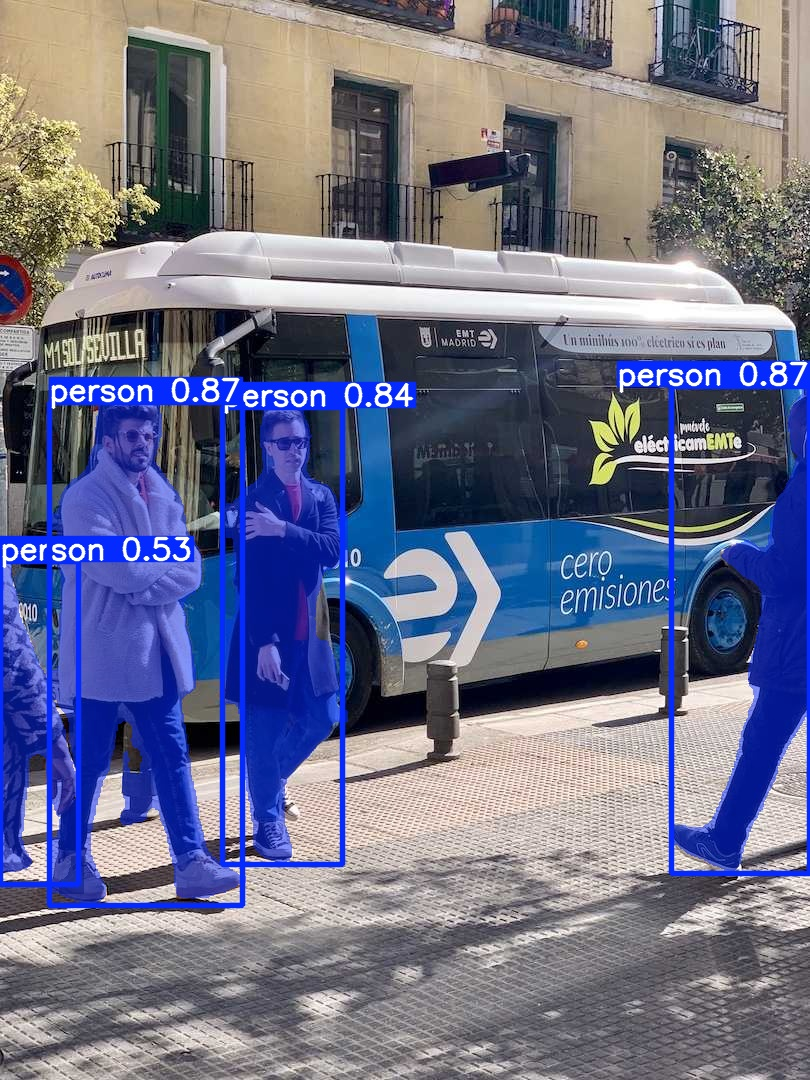

In [ ]:
from IPython.display import Image, display
import glob
import os

# Find saved result image
saved = glob.glob("runs/segment/predict*/*.jpg")
display(Image(saved[-1]))

In [8]:
for r in results_pred:
    print(f"Number of objects detected: {len(r.boxes)}")
    
    for i, (box, mask) in enumerate(zip(r.boxes, r.masks)):
        class_id = int(box.cls)
        class_name = best_model.names[class_id]
        confidence = float(box.conf)
        
        print(f"  [{i}] {class_name:15s} conf={confidence:.2f}  mask_shape={mask.data.shape}")

Number of objects detected: 4
  [0] person          conf=0.87  mask_shape=torch.Size([1, 640, 480])
  [1] person          conf=0.87  mask_shape=torch.Size([1, 640, 480])
  [2] person          conf=0.84  mask_shape=torch.Size([1, 640, 480])
  [3] person          conf=0.53  mask_shape=torch.Size([1, 640, 480])
